In [156]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

['LOS ANGELES', 'SAN FRANSISCO', 'SEATTLE', 'CALGARY', 'MINEAPOLIS', 'DENVER', 'PHOENIX', 'DALLAS']
['TORONTO', 'MONTREAL', 'CHICAGO', 'INDIANAPOLIS', 'ATLANTA', 'WASHIGTON', 'NEW YORK', 'BOSTON']
['MONTERREY', 'NEW ORLEANS', 'MIAMI', 'GUADALAJARA', 'CIUDAD DE MEXICO', 'TEGUCIGALPA', 'HAVANA', 'SANTO DOMINGO']


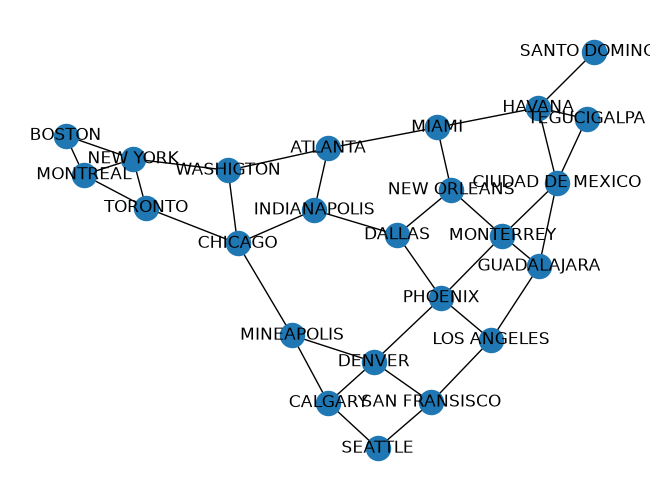

In [5]:
pandemic_graph  = nx.Graph()

red_part = ["los angeles", "san fransisco", "seattle", "calgary", "mineapolis", "denver", "phoenix", "dallas"]
yellow_part = ["monterrey", "new orleans", "miami", "guadalajara", "ciudad de mexico", "tegucigalpa", "havana", "santo domingo"]
blue_part = ["toronto", "montreal", "chicago", "indianapolis", "atlanta", "washigton", "new york", "boston"]





red_part = list(map(lambda x : x.upper(), red_part))
yellow_part = list(map(lambda x : x.upper(), yellow_part))
blue_part = list(map(lambda x : x.upper(), blue_part))

print(red_part)
print(blue_part)
print(yellow_part)


for town in red_part:
    pandemic_graph.add_node(town, style="red")

for town in yellow_part:
    pandemic_graph.add_node(town, style="yellow")

for town in blue_part:
    pandemic_graph.add_node(town, style="blue")


edges = [
    ("SEATTLE", "CALGARY"),
    ("SEATTLE", "SAN FRANSISCO"),
    ("SAN FRANSISCO", "DENVER"),
    ("SAN FRANSISCO", "LOS ANGELES"),
    ("CALGARY", "MINEAPOLIS"),
    ("CALGARY", "DENVER"),
    ("LOS ANGELES", "PHOENIX"),
    ("DALLAS", "PHOENIX"),
    ("DENVER", "PHOENIX"),
    ("DENVER", "MINEAPOLIS"),
    ("CHICAGO", "MINEAPOLIS"),
    ("DALLAS", "INDIANAPOLIS"),
    ("DALLAS", "NEW ORLEANS"),
    ("MONTERREY", "PHOENIX"),
    ("LOS ANGELES", "GUADALAJARA"),
    ("CHICAGO", "INDIANAPOLIS"),
    ("CHICAGO", "TORONTO"),
    ("MONTREAL", "TORONTO"),
    ("MONTREAL", "BOSTON"),
    ("NEW YORK", "TORONTO"),
    ("NEW YORK", "MONTREAL"),
    ("NEW YORK", "BOSTON"),
    ("NEW YORK", "WASHIGTON"),
    ("CHICAGO", "WASHIGTON"),
    ("ATLANTA", "WASHIGTON"),
    ("ATLANTA", "INDIANAPOLIS"),
    ("ATLANTA", "MIAMI"),
    ("NEW ORLEANS", "MIAMI"),
    ("HAVANA", "MIAMI"),
    ("MONTERREY", "NEW ORLEANS"),
    ("MONTERREY", "GUADALAJARA"),
    ("MONTERREY", "CIUDAD DE MEXICO"),
    ("HAVANA", "CIUDAD DE MEXICO"),
    ("TEGUCIGALPA", "CIUDAD DE MEXICO"),
    ("GUADALAJARA", "CIUDAD DE MEXICO"),
    ("TEGUCIGALPA", "HAVANA"),
    ("MIAMI", "HAVANA"),
    ("SANTO DOMINGO", "HAVANA"),

]

pandemic_graph
pandemic_graph.add_edges_from(edges)

nx.draw(pandemic_graph, with_labels=True)

# 1 .Drawing Graphes

## Pandemics

In [14]:
pandemic_graph.nodes['Havana']

{'color': 'yellow', 'x': 315, 'y': 321}

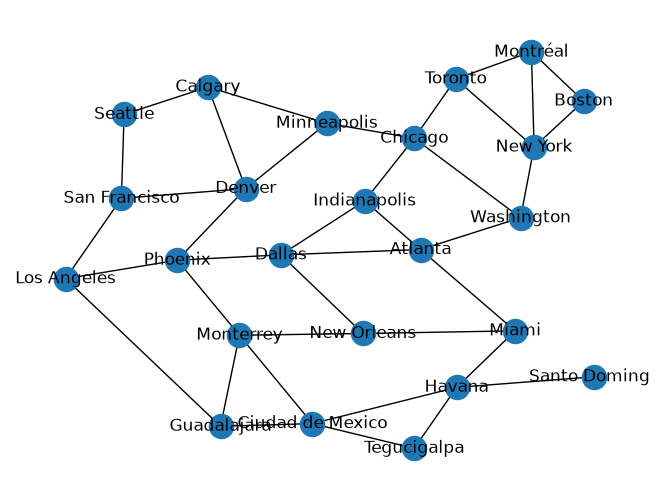

In [154]:
pandemic_graph = nx.read_graphml("./pandemic_board_us.graphml")

pos = {
    node: (float(data["x"]), -float(data["y"])) # je change l'axe y pour que le graphe soit plus lisible
    for node, data in pandemic_graph.nodes(data=True)
}

nx.draw(pandemic_graph, with_labels=True, pos=pos)

## Ticket to Ride, London

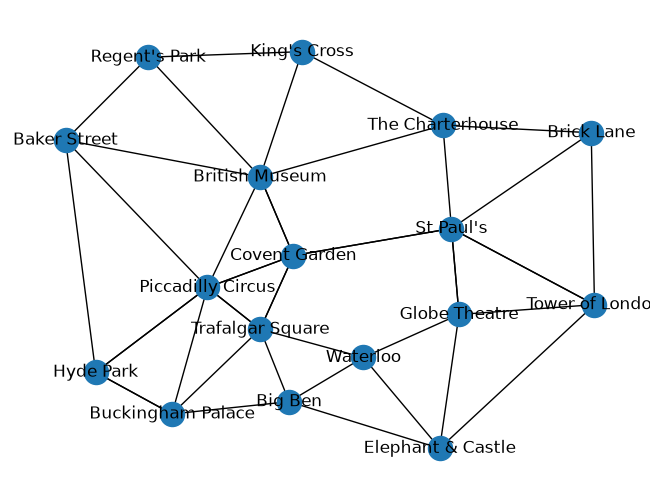

In [18]:
london_graph = nx.read_graphml("./ticket_to_ride_board_london.graphml", force_multigraph=True)

pos = {
    node: (float(data["x"]), -float(data["y"]))
    for node, data in london_graph.nodes(data=True)
}

nx.draw(london_graph, with_labels=True, pos=pos)

On a utilisé un graphe non orienté dans pour la Pandemie et un multigraph pour les données "Ticket to ride, London"


# 2. Graphs Order

In [19]:
order_pandemic_graph = len(pandemic_graph.nodes)
print("The number of nodes in the pandemic graph is:", order_pandemic_graph)   


order_london_graph = len(london_graph.nodes)
print("The number of nodes in the london graph is:", order_london_graph)

The number of nodes in the pandemic graph is: 24
The number of nodes in the london graph is: 17


# 3. Display both graphs as adjacency lists.

In [24]:
pandemic_adj_list = pandemic_graph.adjacency()



for node, neighbors in pandemic_adj_list:
    print(f"{node} - {", ".join(list(neighbors.keys()))}")

Calgary - Seattle, Denver, Minneapolis
Seattle - Calgary, San Francisco
San Francisco - Seattle, Denver, Los Angeles
Denver - Calgary, San Francisco, Minneapolis, Phoenix
Minneapolis - Calgary, Denver, Chicago
Los Angeles - San Francisco, Guadalajara, Phoenix
Phoenix - Denver, Los Angeles, Dallas, Monterrey
Dallas - Phoenix, Atlanta, Indianapolis, New Orleans
Chicago - Minneapolis, Washington, Toronto, Indianapolis
Toronto - Chicago, Montréal, New York
Montréal - Toronto, New York, Boston
Boston - Montréal, New York
New York - Toronto, Montréal, Boston, Washington
Washington - Chicago, New York, Atlanta
Indianapolis - Dallas, Chicago, Atlanta
Atlanta - Dallas, Washington, Indianapolis, Miami
Monterrey - Phoenix, New Orleans, Ciudad de Mexico, Guadalajara
New Orleans - Dallas, Monterrey, Miami
Miami - Atlanta, New Orleans, Havana
Guadalajara - Los Angeles, Monterrey, Ciudad de Mexico
Ciudad de Mexico - Monterrey, Guadalajara, Havana, Tegucigalpa
Tegucigalpa - Ciudad de Mexico, Havana
Ha

In [25]:
london_adj_list = london_graph.adjacency()



for node, neighbors in london_adj_list:
    print(f"{node} - {", ".join(list(neighbors.keys()))}")

Regent's Park - Baker Street, King's Cross, British Museum
King's Cross - Regent's Park, The Charterhouse, British Museum
Baker Street - Regent's Park, British Museum, Piccadilly Circus, Hyde Park
British Museum - Regent's Park, King's Cross, Baker Street, The Charterhouse, Covent Garden, Piccadilly Circus
Piccadilly Circus - Baker Street, British Museum, Hyde Park, Buckingham Palace, Trafalgar Square, Covent Garden
Hyde Park - Baker Street, Piccadilly Circus, Buckingham Palace
Buckingham Palace - Piccadilly Circus, Hyde Park, Trafalgar Square, Big Ben
Covent Garden - British Museum, Piccadilly Circus, St Paul's, Trafalgar Square
Trafalgar Square - Piccadilly Circus, Buckingham Palace, Covent Garden, Big Ben, Waterloo
Big Ben - Buckingham Palace, Trafalgar Square, Elephant & Castle, Waterloo
Waterloo - Trafalgar Square, Big Ben, Globe Theatre, Elephant & Castle
Globe Theatre - Waterloo, Elephant & Castle, St Paul's, Tower of London
St Paul's - Covent Garden, Globe Theatre, The Charterh

# 4. Determine and display the adjacency A, incidence M, and combinatorial Laplacian L matrices.

## Pandemic graph

In [86]:
def plot_sparse_matrix(matrix, title, annotate=False):

    

    fig, ax = plt.subplots(figsize=(19, 19))
    im = ax.imshow(matrix, cmap='viridis')
    ax = plt.gca()
    ax.set_title(title)

    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                if matrix[i, j] != 0:
                    text = ax.text(j, i, "{}".format(round(matrix[i, j], 2)),
                                ha="center", va="center", color="r")
    plt.show()

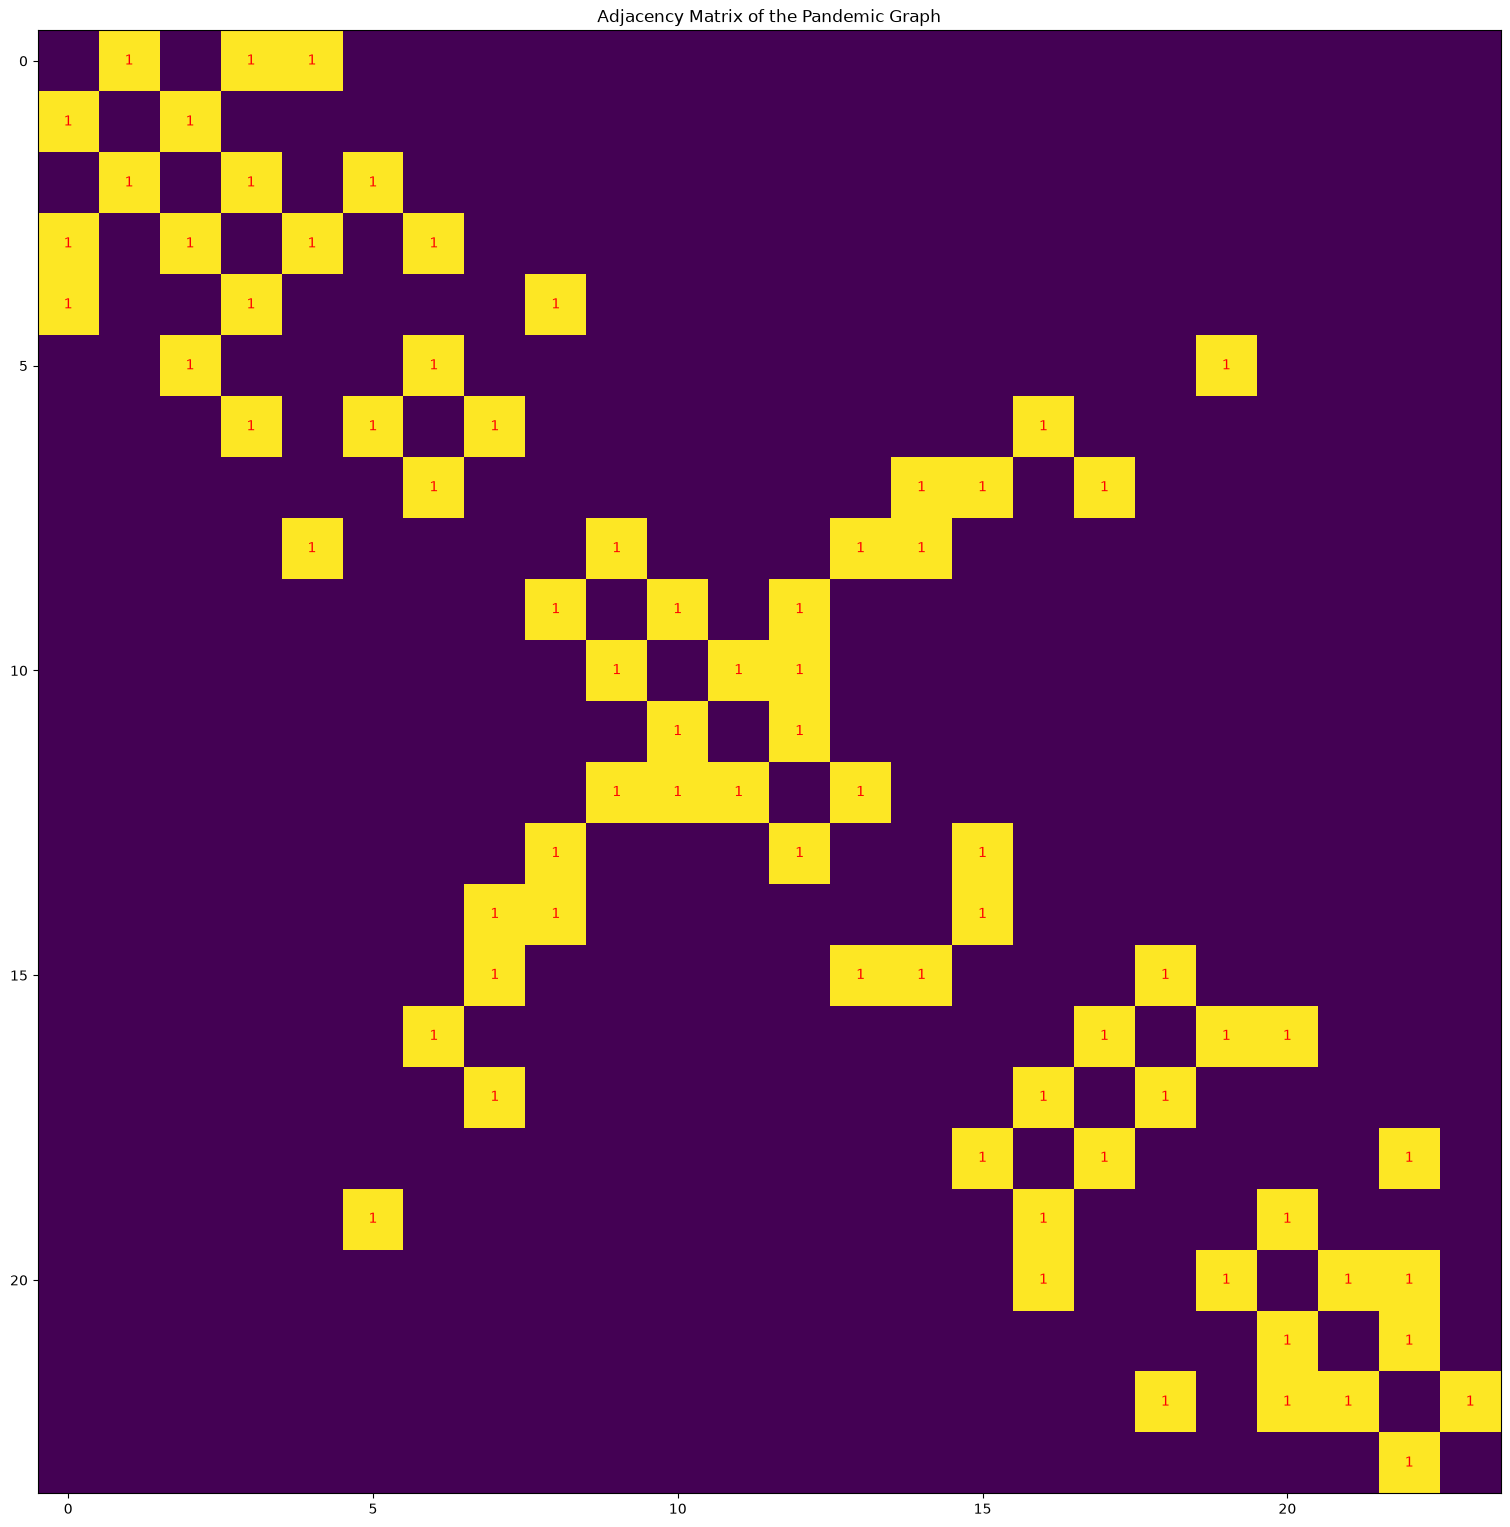

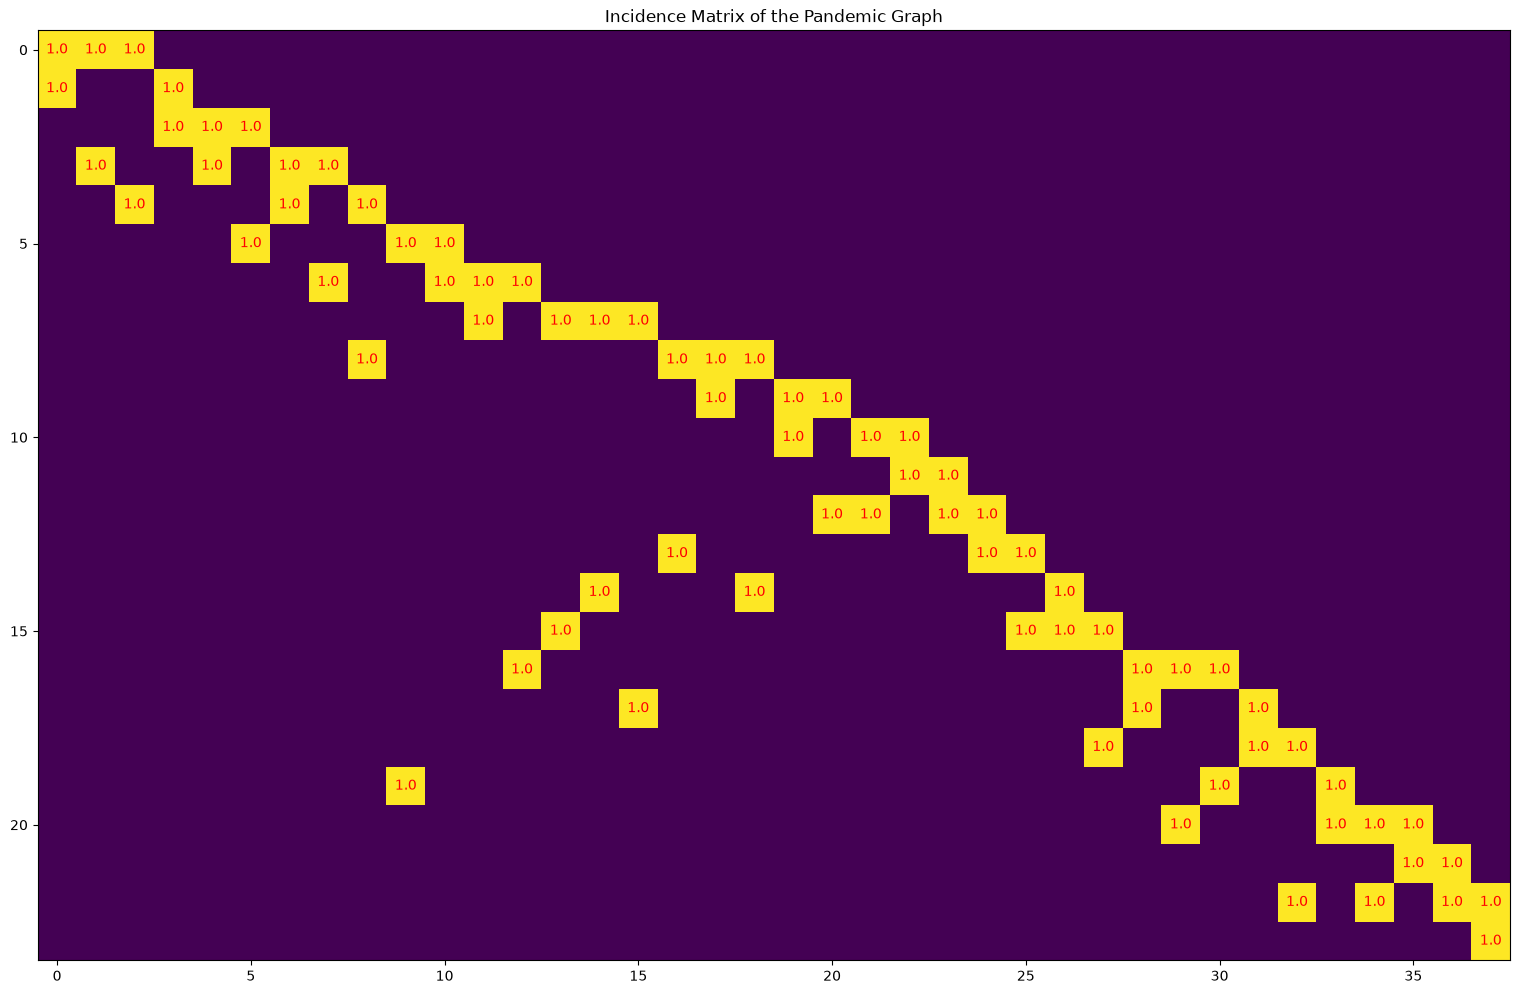

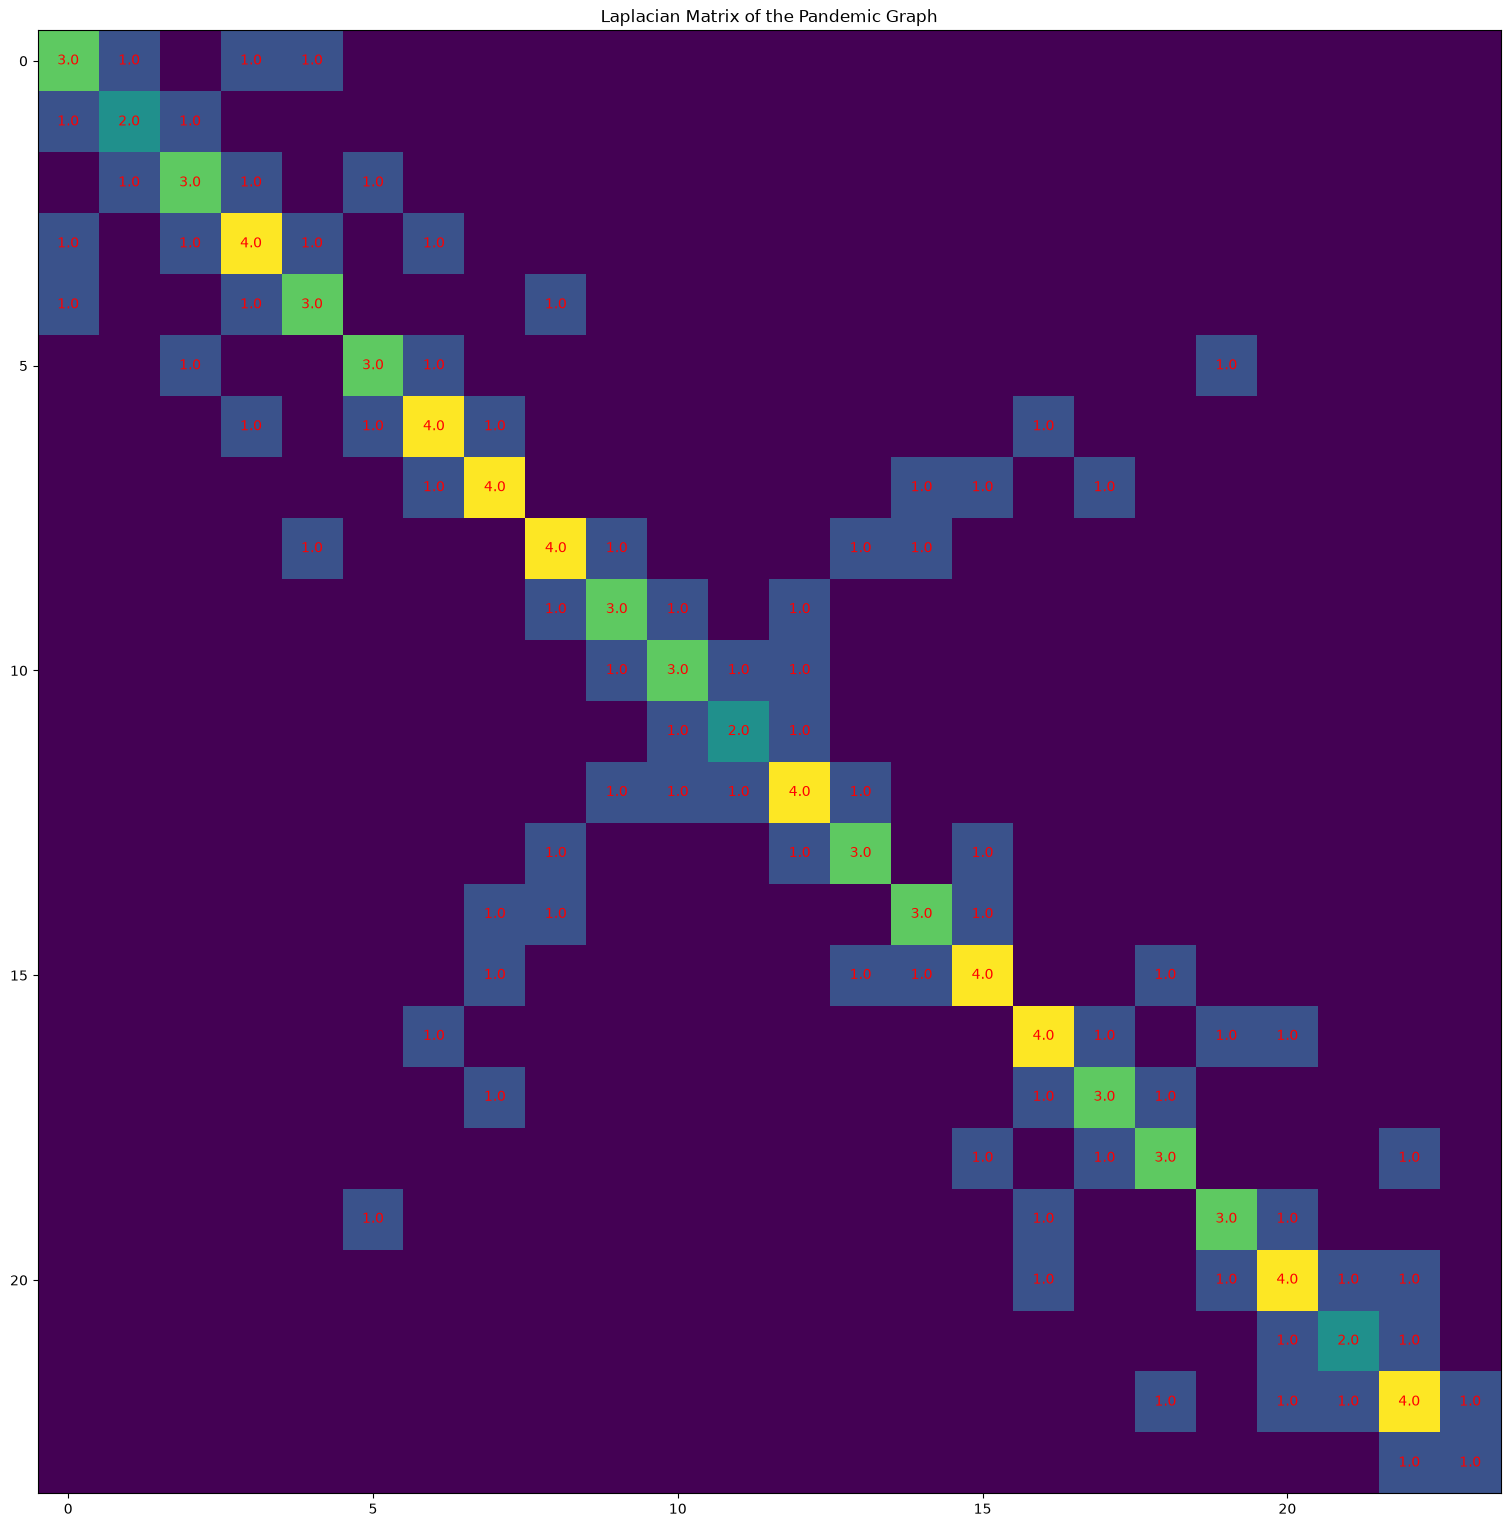

In [87]:

A_pandemic =nx.adjacency_matrix(pandemic_graph).todense()


plot_sparse_matrix(A_pandemic, "Adjacency Matrix of the Pandemic Graph", annotate=True)

M_pandemic = nx.incidence_matrix(pandemic_graph).todense()
# print(M_pandemic.shape)
plot_sparse_matrix(M_pandemic, "Incidence Matrix of the Pandemic Graph", annotate=True)

L_pandemic = M_pandemic @ M_pandemic.T
plot_sparse_matrix(L_pandemic, "Laplacian Matrix of the Pandemic Graph", annotate=True)

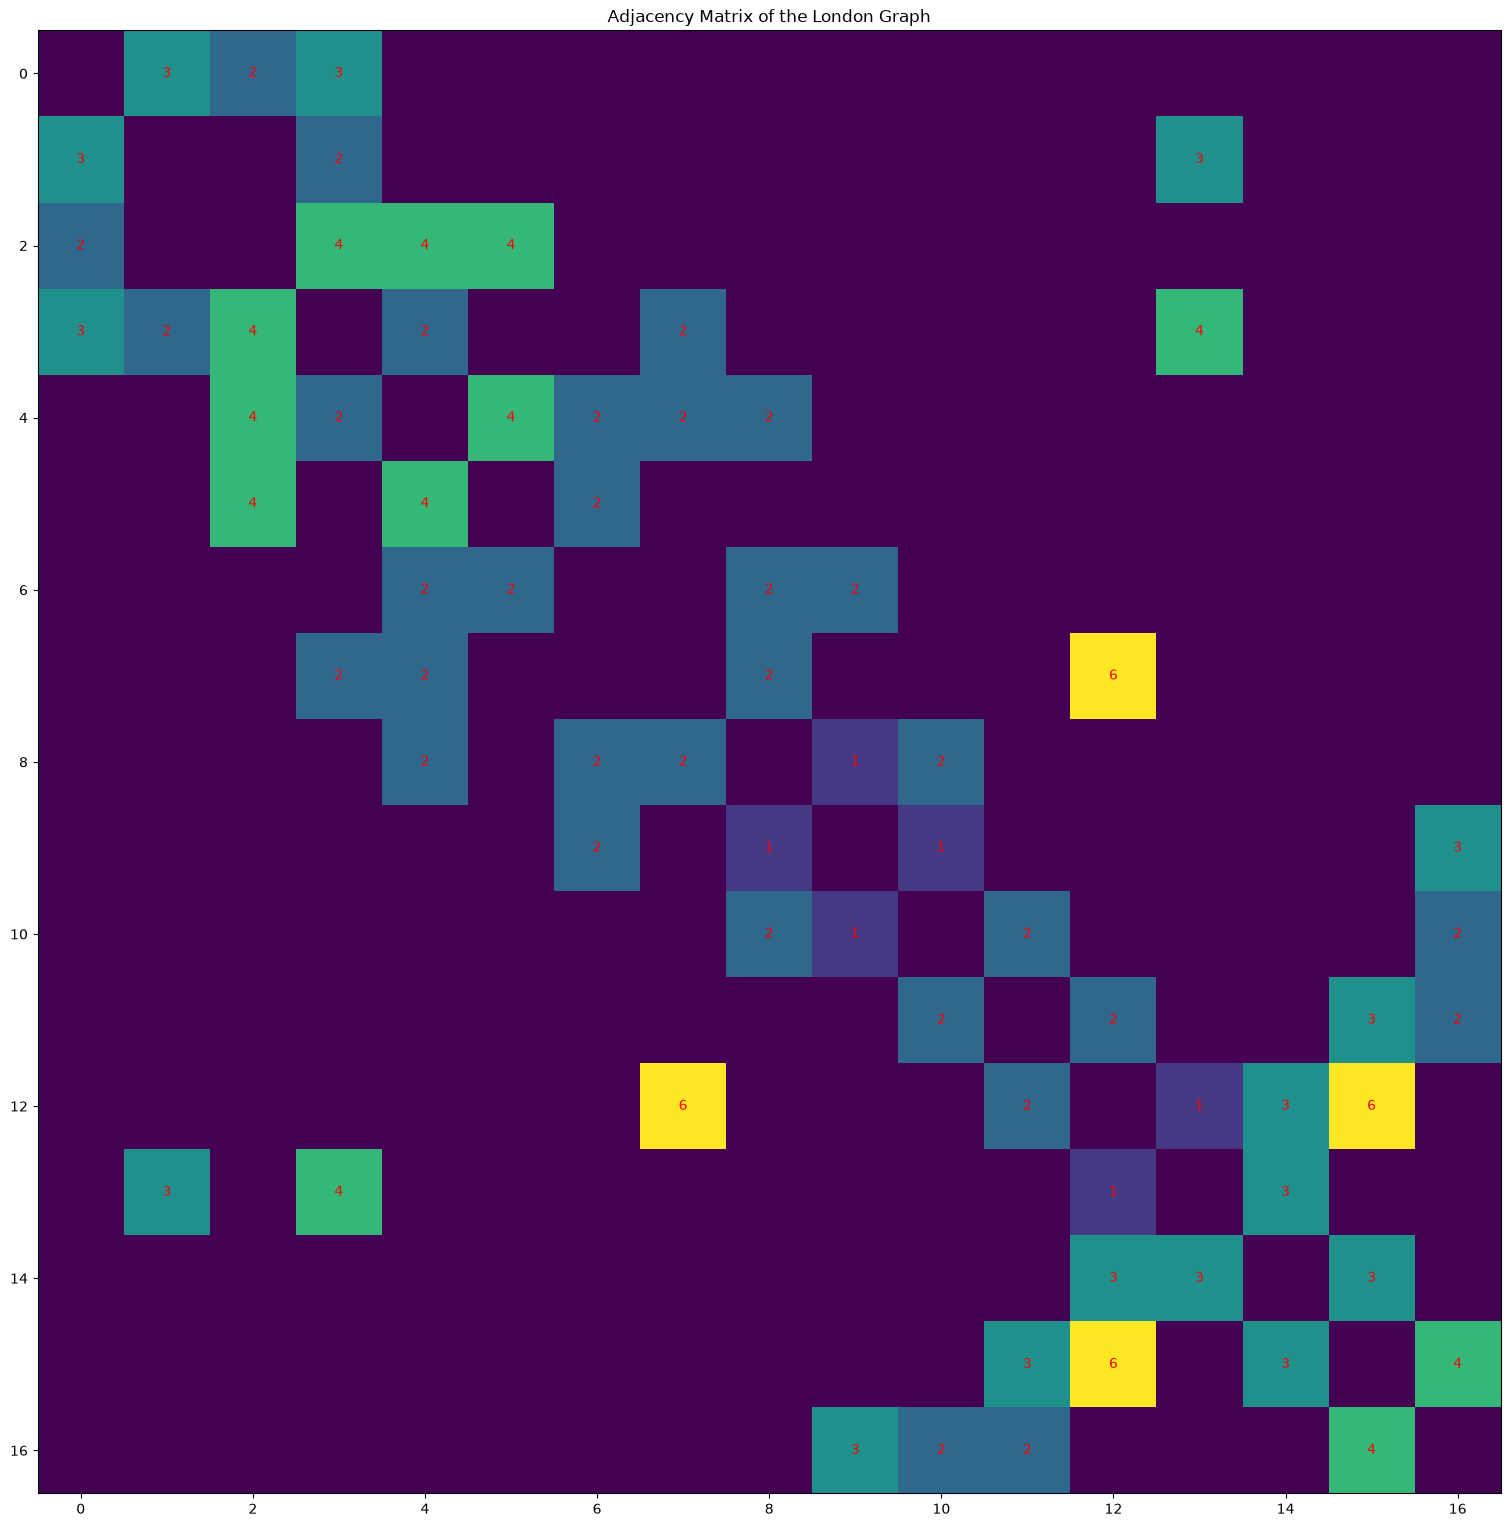

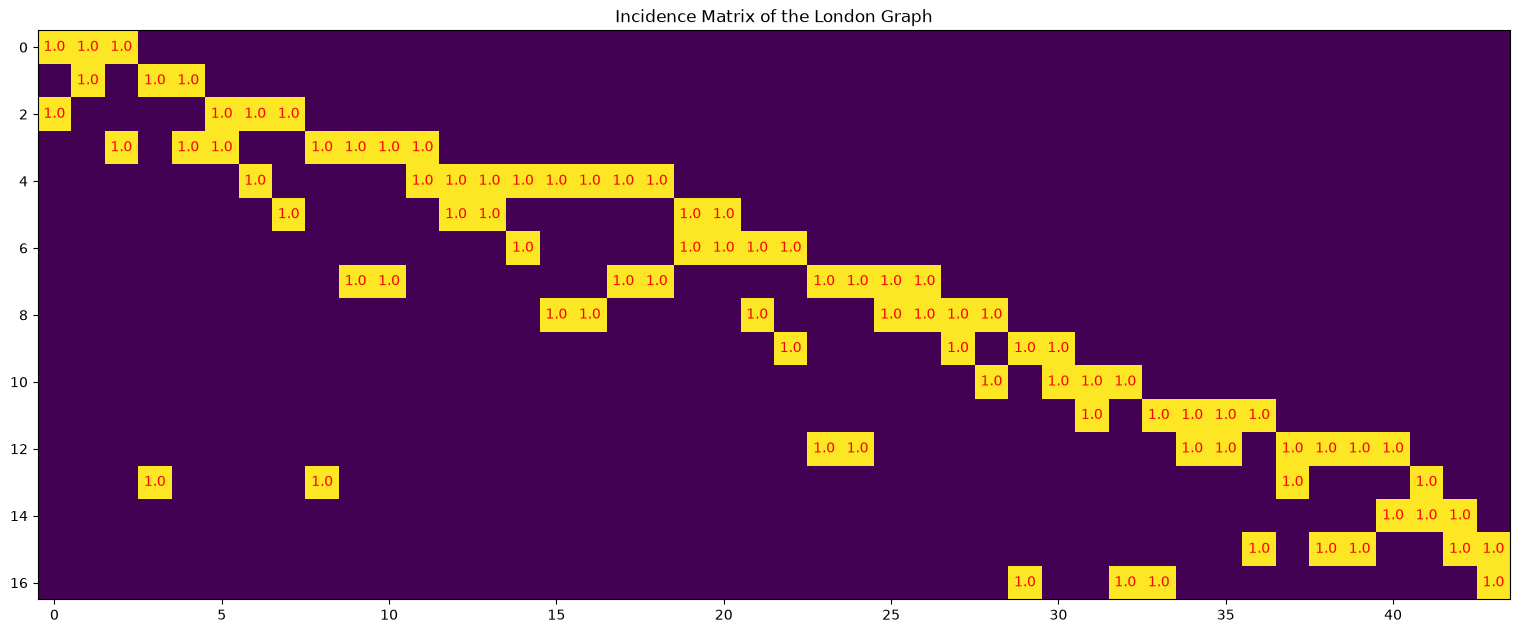

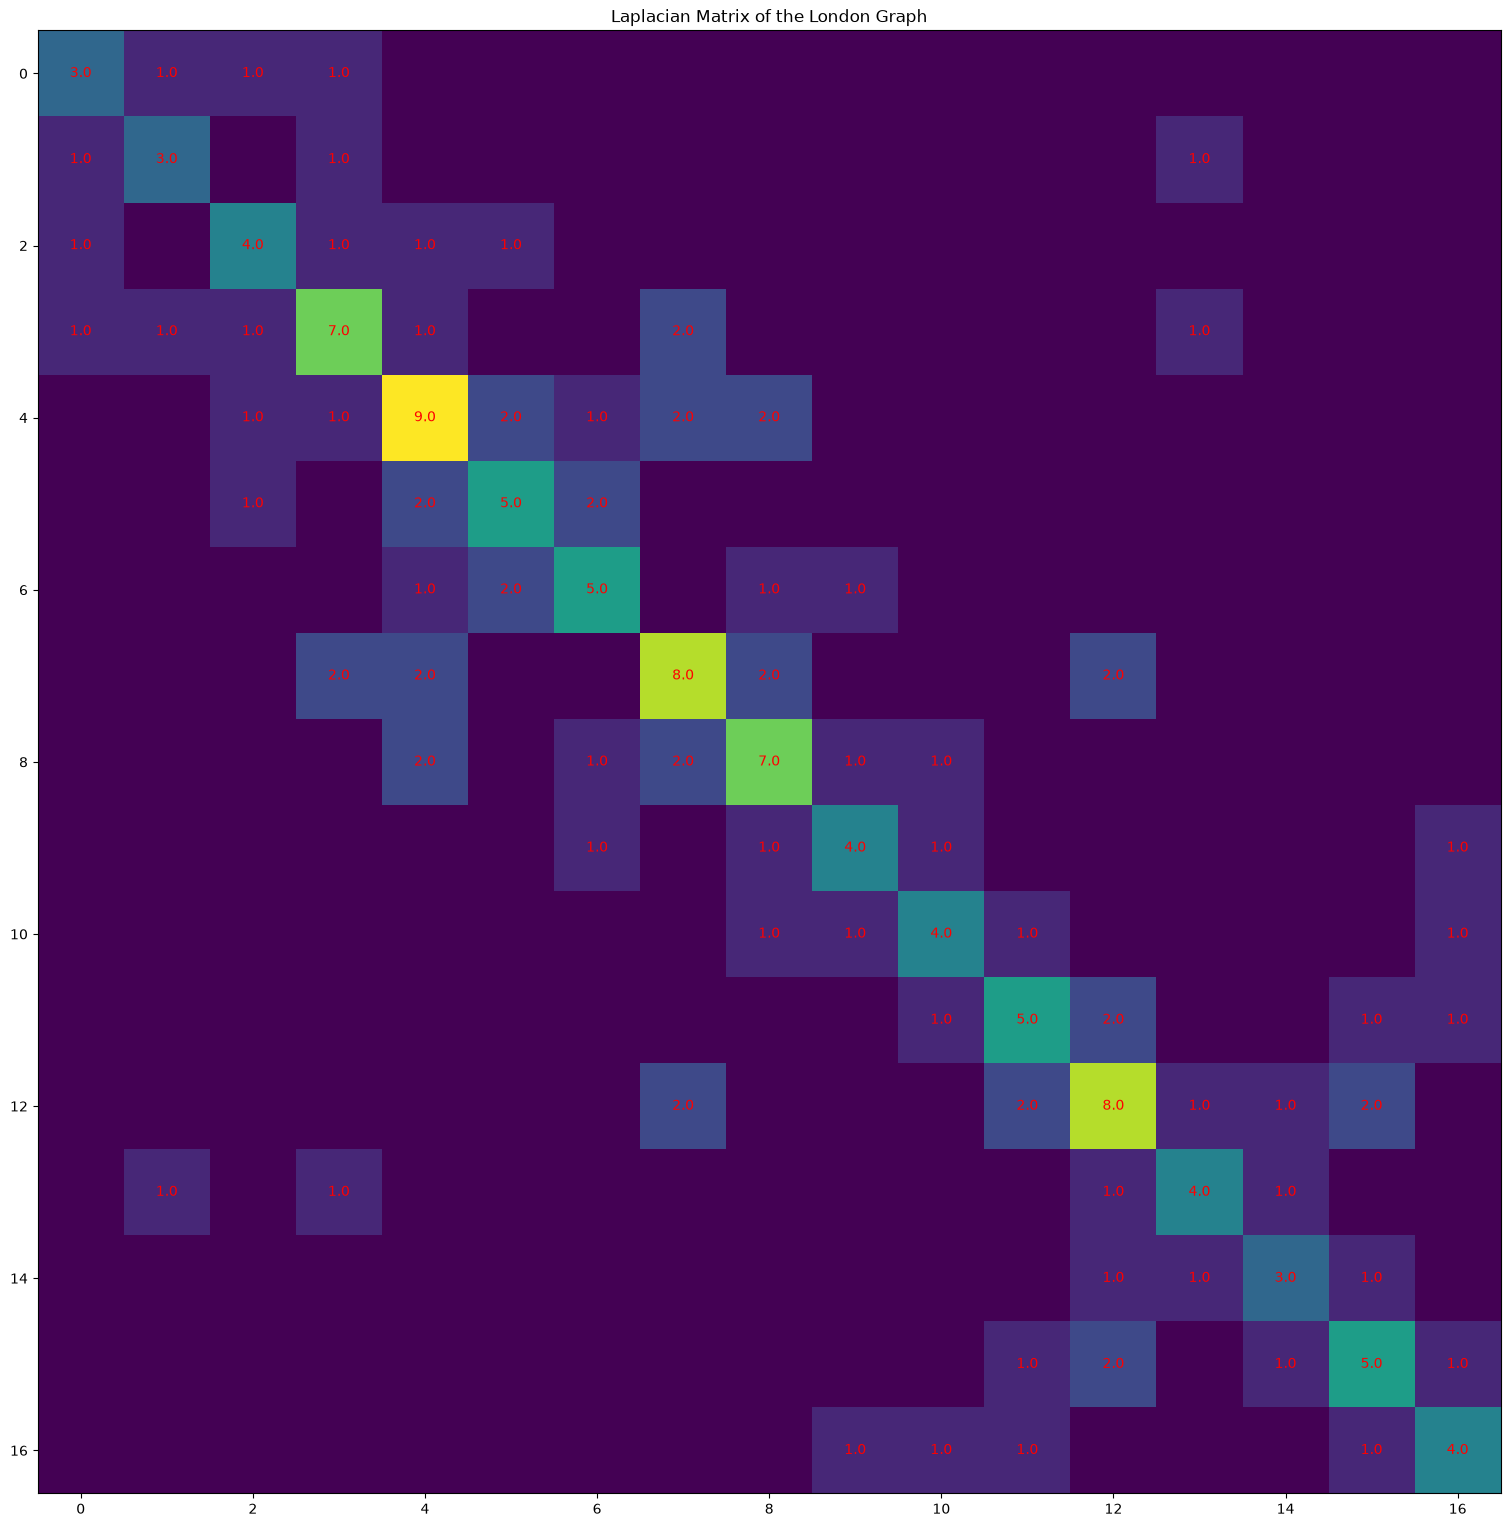

In [88]:

A_london =nx.adjacency_matrix(london_graph).todense()
plot_sparse_matrix(A_london, "Adjacency Matrix of the London Graph", annotate=True)

M_london = nx.incidence_matrix(london_graph).todense()
# print(M_london.shape)
plot_sparse_matrix(M_london, "Incidence Matrix of the London Graph", annotate=True)

L_london = M_london @ M_london.T
plot_sparse_matrix(L_london, "Laplacian Matrix of the London Graph", annotate=True)

# 5. Using the relationship L =D −A, print the degree matrix D for the ”Pandemic” graph.

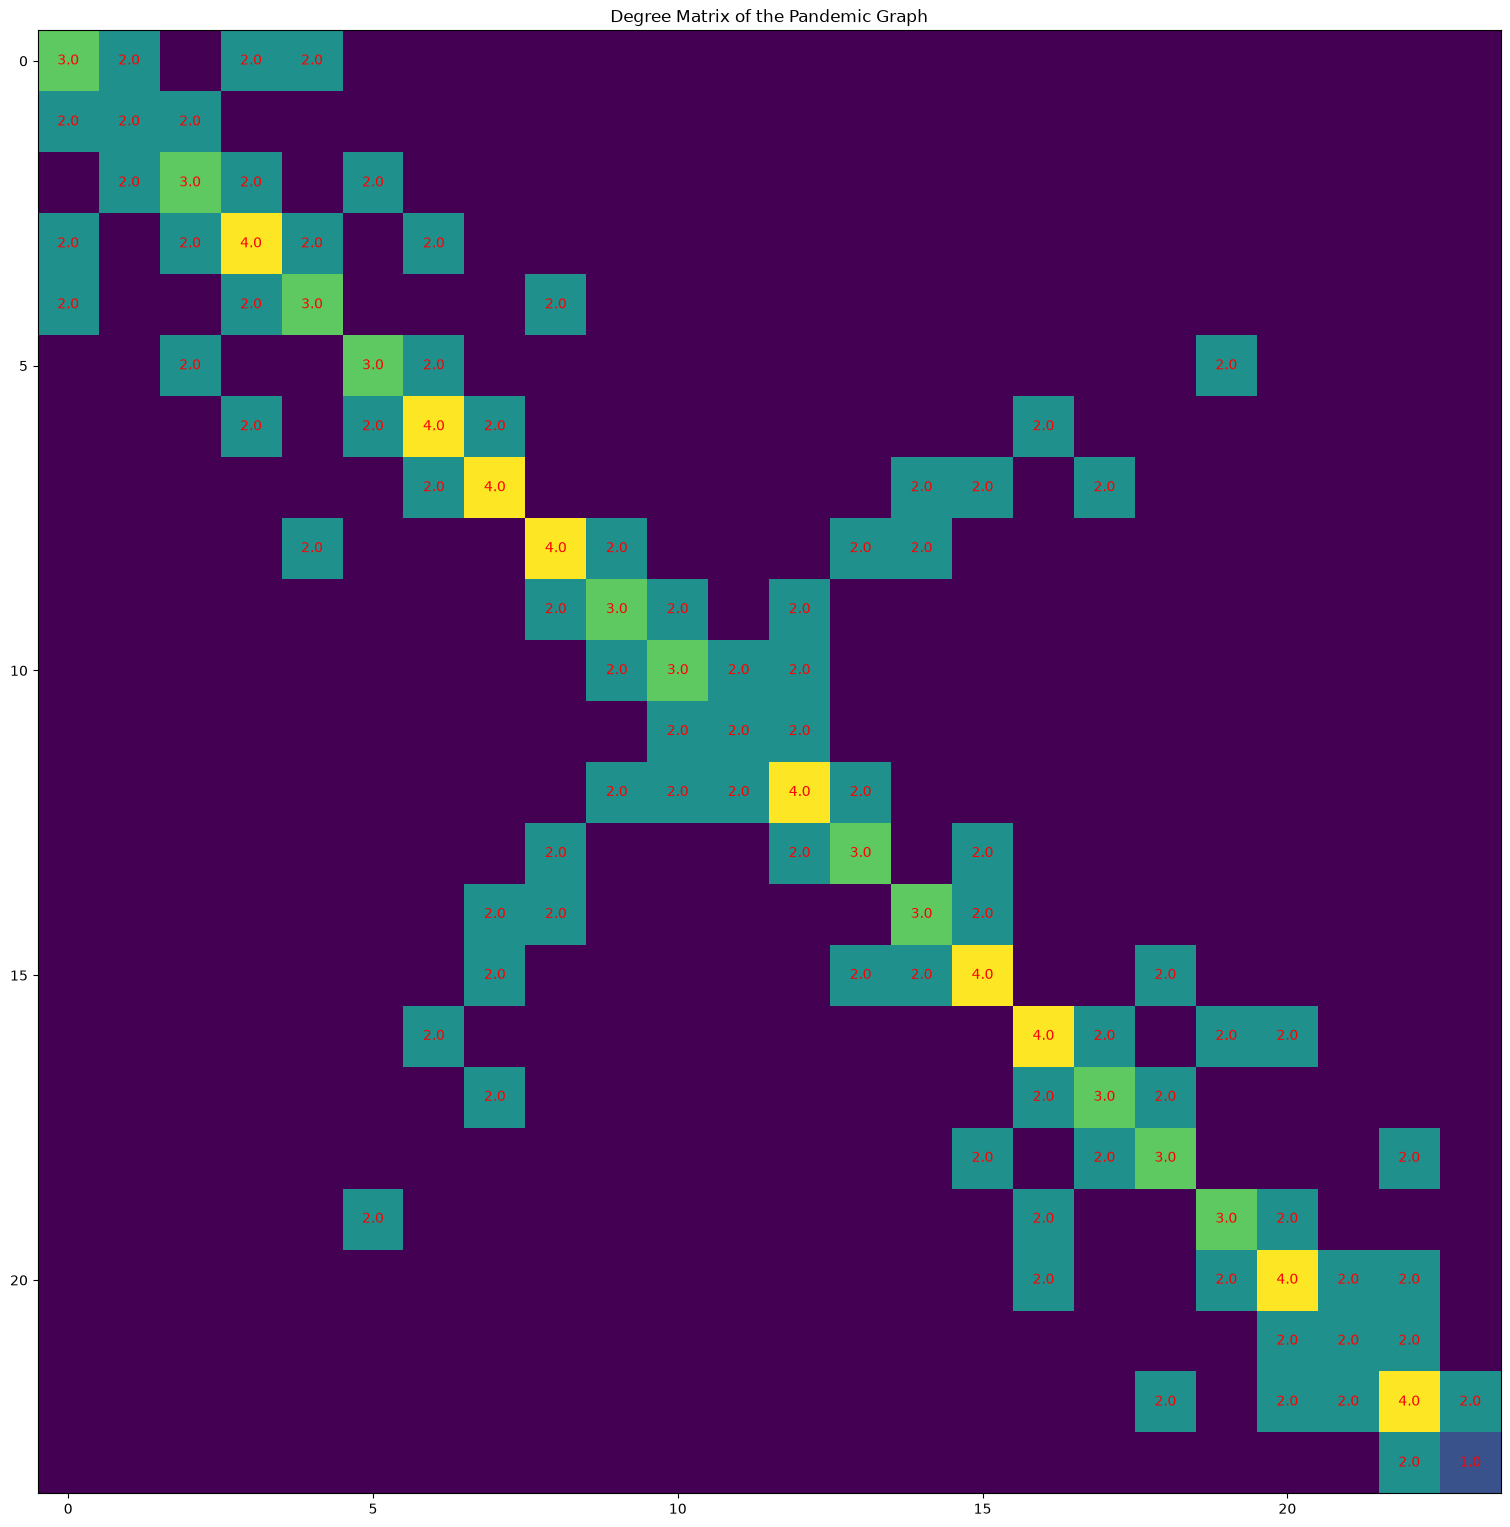

In [89]:
D_pandemic = L_pandemic + A_pandemic
plot_sparse_matrix(D_pandemic, "Degree Matrix of the Pandemic Graph", annotate=True)

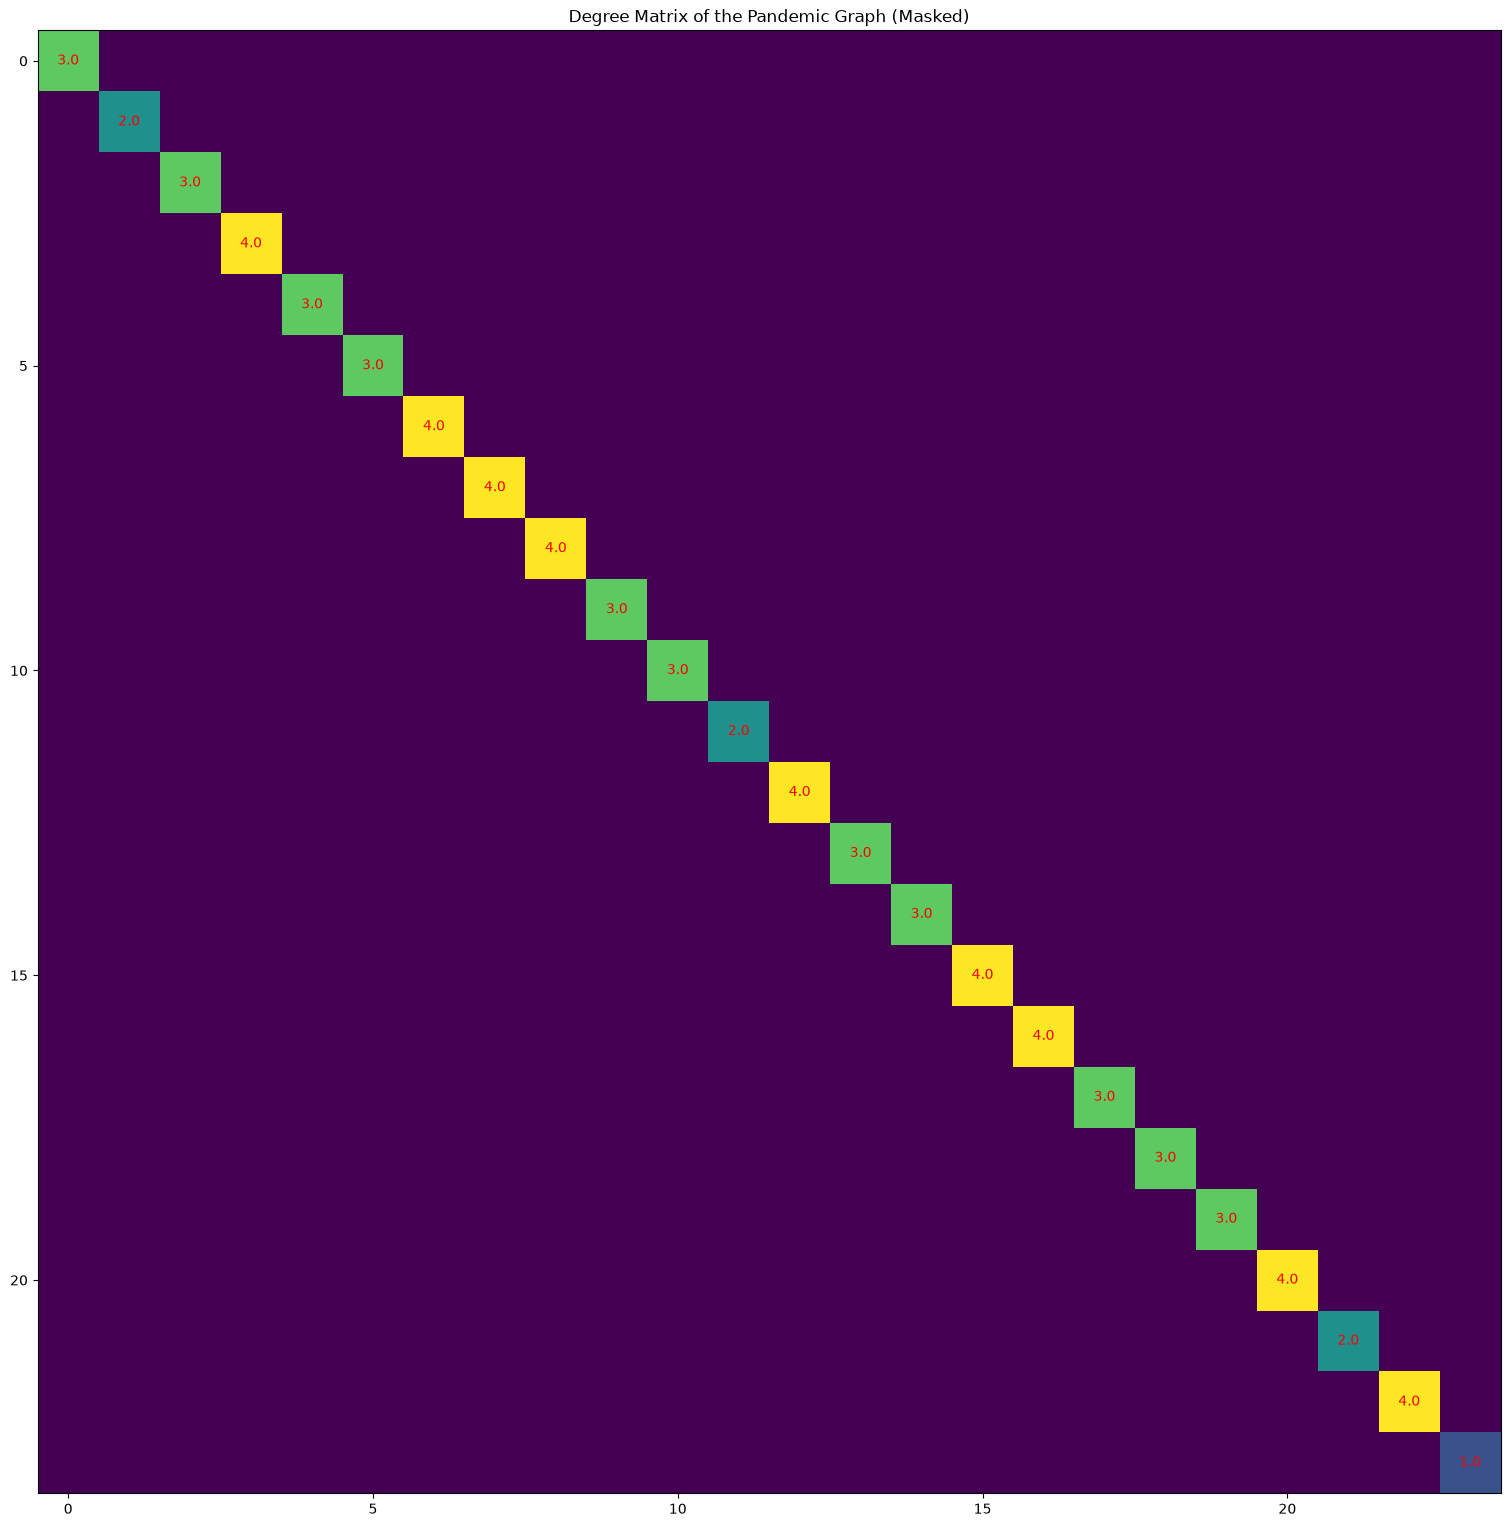

In [90]:
mask = np.zeros_like(D_pandemic) + np.eye(D_pandemic.shape[0])
D_masked = np.multiply(D_pandemic, mask)
plot_sparse_matrix(D_masked, "Degree Matrix of the Pandemic Graph (Masked)", annotate=True)

# 6. Construct a |V |×3feature matrix X ∈R|V|×3 for ”Pandemic” representing the one-hot encoding of city colors (red, blue, yellow)

In [91]:
pandemic_graph.nodes['Calgary']

{'color': 'red', 'x': -237, 'y': -359}

In [92]:
feature_matrix = np.zeros((len(pandemic_graph.nodes), 3))

color_encoding = {'blue': [1, 0, 0], 'red': [0, 1, 0], 'yellow': [0, 0, 1]}

for i, node in enumerate(pandemic_graph.nodes):
    feature_matrix[i] = color_encoding[pandemic_graph.nodes[node]['color']]

feature_matrix

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

# 7. Compute the symmetric normalized Laplacian Lsym=D−1/2LD−1/2 =I −D−1/2AD−1/2 for ”Pandemic”

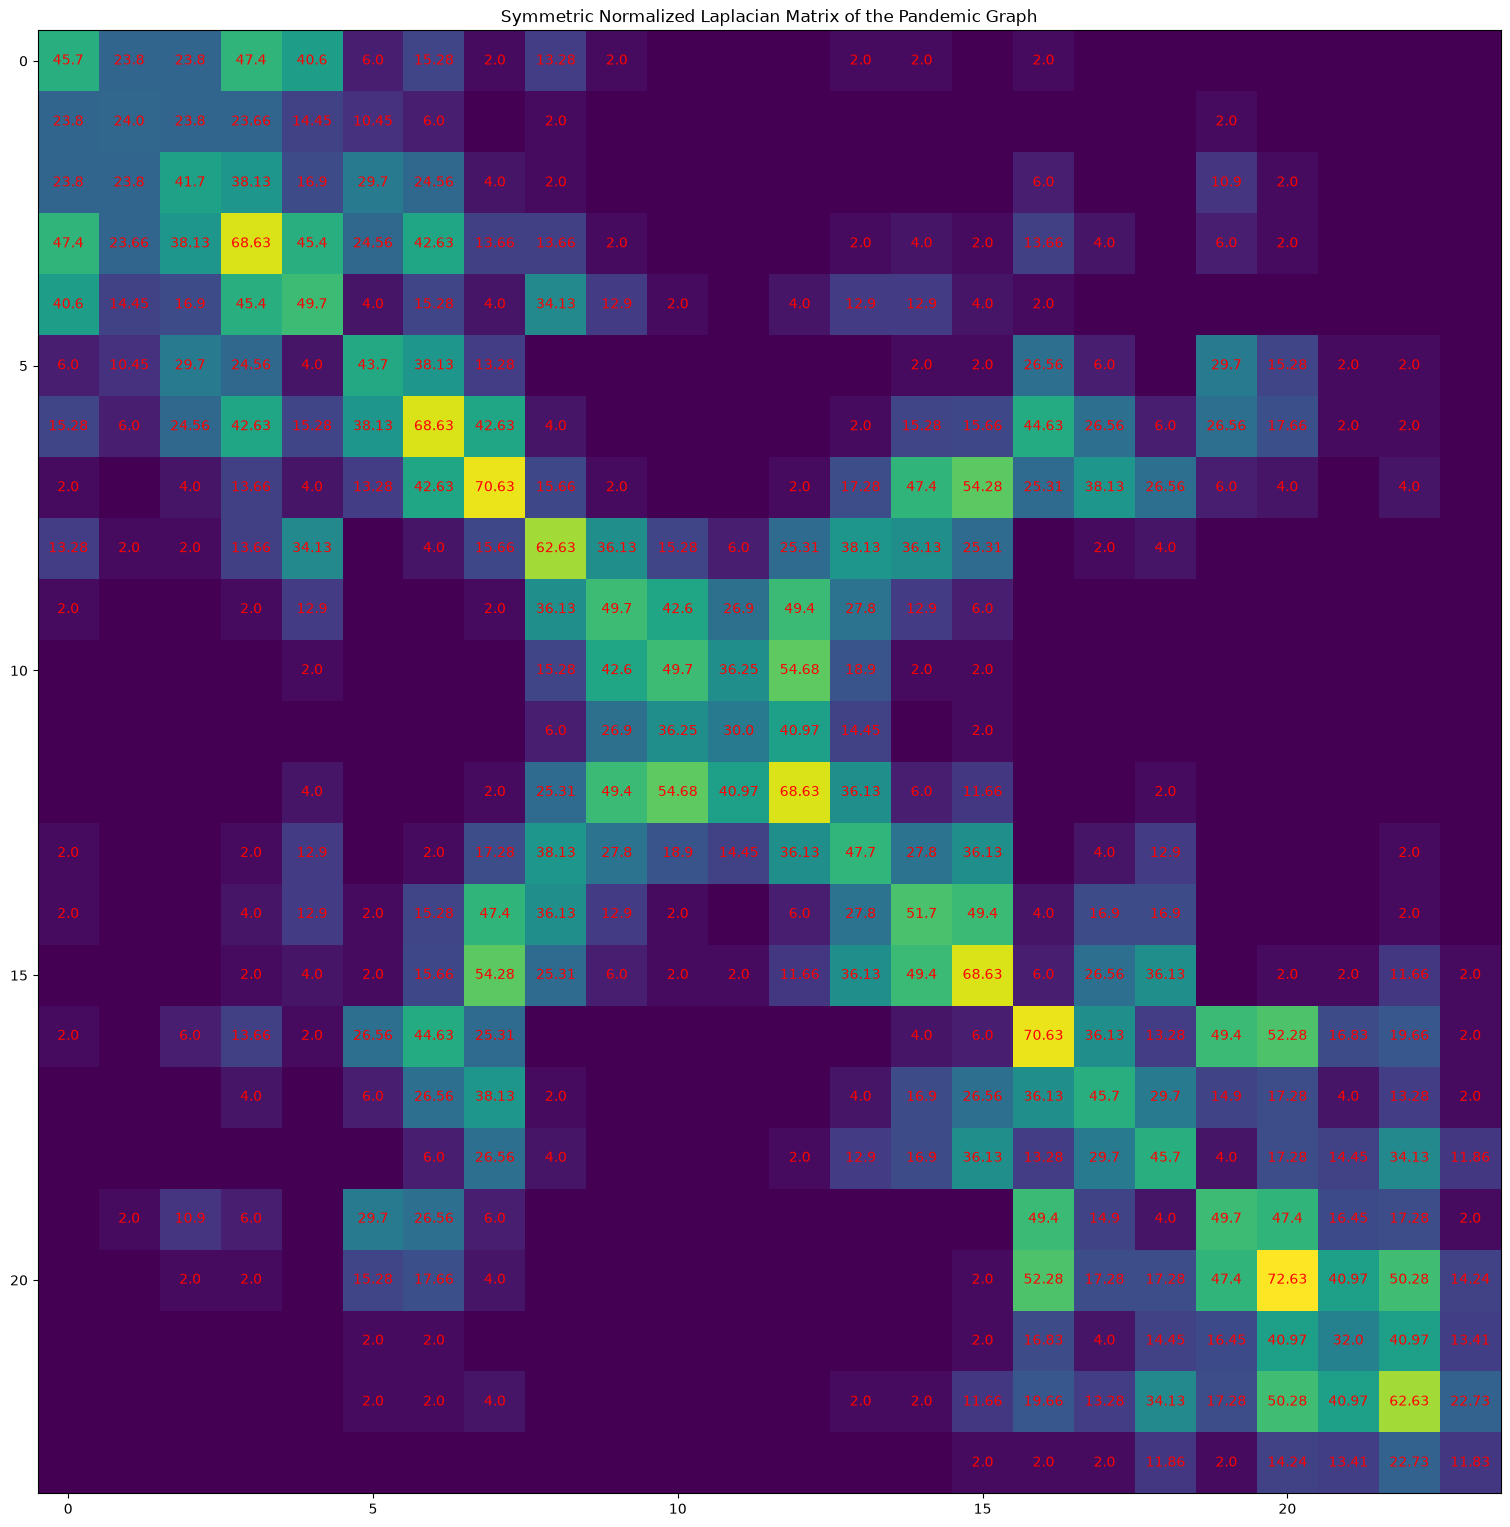

In [97]:
L_sym_1 = np.sqrt(D_pandemic)@ L_pandemic @ np.sqrt(D_pandemic)
plot_sparse_matrix(L_sym_1, "Symmetric Normalized Laplacian Matrix of the Pandemic Graph", annotate=True)

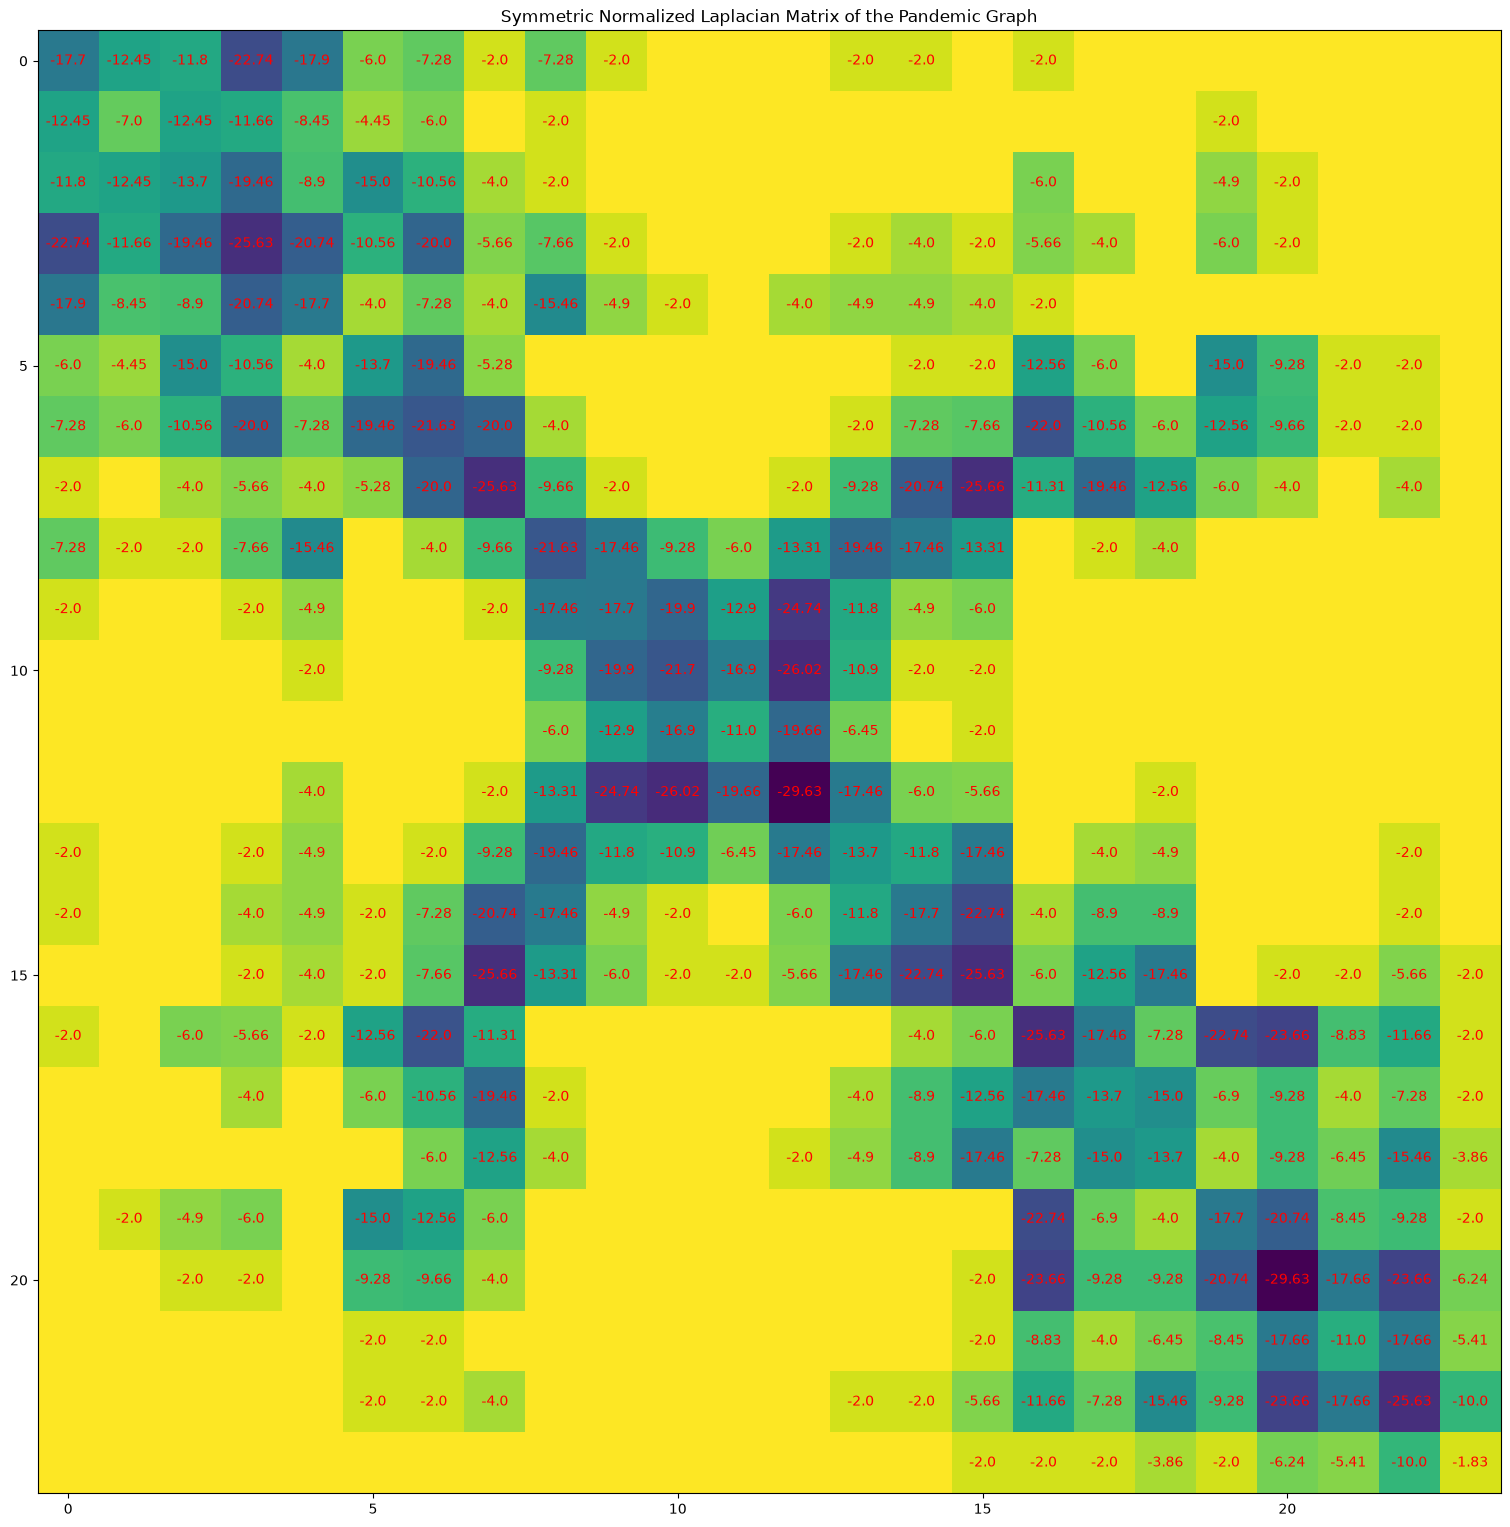

In [100]:
L_sym_2 = np.eye(D_pandemic.shape[0]) - np.sqrt(D_pandemic)@ A_pandemic @ np.sqrt(D_pandemic)

plot_sparse_matrix(L_sym_2, "Symmetric Normalized Laplacian Matrix of the Pandemic Graph", annotate=True)

I dont get the same result using the two formula

# 8. Determine the minimum, maximum, and average degree for both graphs

## Pandemix

In [101]:
min_degree_pandemic = np.min(np.sum(A_pandemic, axis=1))
max_degree_pandemic = np.max(np.sum(A_pandemic, axis=1))
avg_degree_pandemic = np.mean(np.sum(A_pandemic, axis=1))

print("Minimum degree of the Pandemic Graph:", min_degree_pandemic)
print("Maximum degree of the Pandemic Graph:", max_degree_pandemic)
print("Average degree of the Pandemic Graph:", avg_degree_pandemic)

Minimum degree of the Pandemic Graph: 1
Maximum degree of the Pandemic Graph: 4
Average degree of the Pandemic Graph: 3.1666666666666665


## Ticket to Ride, London

In [102]:
min_degree_london = np.min(np.sum(A_london, axis=1))
max_degree_london = np.max(np.sum(A_london, axis=1))
avg_degree_london = np.mean(np.sum(A_london, axis=1))

print("Minimum degree of the london Graph:", min_degree_london)
print("Maximum degree of the london Graph:", max_degree_london)
print("Average degree of the london Graph:", avg_degree_london)

Minimum degree of the london Graph: 7
Maximum degree of the london Graph: 18
Average degree of the london Graph: 11.176470588235293


# 9. Display the eccentricity of all nodes in both graphs

# Pandemic

In [104]:
eccentricity_pandemic = nx.eccentricity(pandemic_graph)
print("Eccentricity of the Pandemic Graph:")
for node, ecc in eccentricity_pandemic.items():
    print(f"{node}: {ecc}")

Eccentricity of the Pandemic Graph:
Calgary: 6
Seattle: 6
San Francisco: 6
Denver: 5
Minneapolis: 6
Los Angeles: 6
Phoenix: 5
Dallas: 4
Chicago: 5
Toronto: 6
Montréal: 7
Boston: 7
New York: 6
Washington: 5
Indianapolis: 4
Atlanta: 5
Monterrey: 6
New Orleans: 5
Miami: 6
Guadalajara: 7
Ciudad de Mexico: 6
Tegucigalpa: 6
Havana: 5
Santo Domingo: 6


## Ticket to Ride, London

In [105]:
eccentricity_london = nx.eccentricity(london_graph)
print("Eccentricity of the London Graph:")
for node, ecc in eccentricity_london.items():
    print(f"{node}: {ecc}")

Eccentricity of the London Graph:
Regent's Park: 5
King's Cross: 4
Baker Street: 4
British Museum: 4
Piccadilly Circus: 3
Hyde Park: 4
Buckingham Palace: 4
Covent Garden: 3
Trafalgar Square: 3
Big Ben: 4
Waterloo: 4
Globe Theatre: 4
St Paul's: 3
The Charterhouse: 4
Brick Lane: 4
Tower of London: 4
Elephant & Castle: 5


# 10. Display the diameter, radius, and girth (length of the shortest cycle) of both graphs

## Pandemic

In [106]:
diameter_pandemic = nx.diameter(pandemic_graph)
radius_pandemic = nx.radius(pandemic_graph)
girth_pandemic = nx.girth(pandemic_graph)

print("Diameter of the Pandemic Graph:", diameter_pandemic)
print("Radius of the Pandemic Graph:", radius_pandemic)
print("Girth of the Pandemic Graph:", girth_pandemic)

Diameter of the Pandemic Graph: 7
Radius of the Pandemic Graph: 4
Girth of the Pandemic Graph: 3


## Ticket to Ride, London

In [108]:
diameter_london = nx.diameter(london_graph)
radius_london = nx.radius(london_graph)
# girth_london = nx.girth(london_graph)

print("Diameter of the london Graph:", diameter_london)
print("Radius of the london Graph:", radius_london)
# print("Girth of the london Graph:", girth_london)

Diameter of the london Graph: 5
Radius of the london Graph: 3


The girth is not defined for multiGraph

# 11. Using the appropriate NetworkX function, determine whether these graphs are connected or not, and display the answer.

## Pandemic

In [ ]:


is_connected_pandemic = nx.is_connected(pandemic_graph)
print("the Pandemic Graph is connected ?", is_connected_pandemic)

the Pandemic Graph is connected ? True


## Ticket to Ride, London

In [111]:
is_connected_london = nx.is_connected(london_graph)
print("the London Graph is connected ?", is_connected_london)

the London Graph is connected ? True


# 12. Compute the graph density manually and verify using nx.density().

In [112]:
pandemic_graph_density = nx.density(pandemic_graph)
print("Density of the Pandemic Graph:", pandemic_graph_density)

Density of the Pandemic Graph: 0.13768115942028986


In [113]:
london_graph_density = nx.density(london_graph)
print("Density of the london Graph:", london_graph_density)

Density of the london Graph: 0.3235294117647059


# 13. List the nodes of these graphs in descending order of degree. Do the same for the centrality values

## Pandemic

In [118]:
node_degree = dict(pandemic_graph.degree())
sorted_degree = sorted(node_degree.items(), key=lambda x: x[1], reverse=True)

print("Node degrees in the Pandemic Graph:")
for node, degree in sorted_degree:
    print(f"{node}: {degree}")

Node degrees in the Pandemic Graph:
Denver: 4
Phoenix: 4
Dallas: 4
Chicago: 4
New York: 4
Atlanta: 4
Monterrey: 4
Ciudad de Mexico: 4
Havana: 4
Calgary: 3
San Francisco: 3
Minneapolis: 3
Los Angeles: 3
Toronto: 3
Montréal: 3
Washington: 3
Indianapolis: 3
New Orleans: 3
Miami: 3
Guadalajara: 3
Seattle: 2
Boston: 2
Tegucigalpa: 2
Santo Domingo: 1


In [119]:
node_centrality = nx.degree_centrality(pandemic_graph)
sorted_centrality = sorted(node_centrality.items(), key=lambda x: x[1], reverse=True)

print("Node centrality in the Pandemic Graph:")

for node, centrality in sorted_centrality:
    print(f"{node}: {centrality}")

Node centrality in the Pandemic Graph:
Denver: 0.17391304347826086
Phoenix: 0.17391304347826086
Dallas: 0.17391304347826086
Chicago: 0.17391304347826086
New York: 0.17391304347826086
Atlanta: 0.17391304347826086
Monterrey: 0.17391304347826086
Ciudad de Mexico: 0.17391304347826086
Havana: 0.17391304347826086
Calgary: 0.13043478260869565
San Francisco: 0.13043478260869565
Minneapolis: 0.13043478260869565
Los Angeles: 0.13043478260869565
Toronto: 0.13043478260869565
Montréal: 0.13043478260869565
Washington: 0.13043478260869565
Indianapolis: 0.13043478260869565
New Orleans: 0.13043478260869565
Miami: 0.13043478260869565
Guadalajara: 0.13043478260869565
Seattle: 0.08695652173913043
Boston: 0.08695652173913043
Tegucigalpa: 0.08695652173913043
Santo Domingo: 0.043478260869565216


## Ticket london

In [123]:
node_degree = dict(london_graph.degree())
sorted_degree = sorted(node_degree.items(), key=lambda x: x[1], reverse=True)

print("Node degrees in the London Graph:")
for node, degree in sorted_degree:
    print(f"{node}: {degree}")



Node degrees in the London Graph:
Piccadilly Circus: 9
Covent Garden: 8
St Paul's: 8
British Museum: 7
Trafalgar Square: 7
Hyde Park: 5
Buckingham Palace: 5
Globe Theatre: 5
Tower of London: 5
Baker Street: 4
Big Ben: 4
Waterloo: 4
The Charterhouse: 4
Elephant & Castle: 4
Regent's Park: 3
King's Cross: 3
Brick Lane: 3


In [124]:

print("Node centrality in the London Graph:")
node_centrality = nx.degree_centrality(london_graph)
sorted_centrality = sorted(node_centrality.items(), key=lambda x: x[1], reverse=True)

for node, centrality in sorted_centrality:
    print(f"{node}: {centrality}")

Node centrality in the London Graph:
Piccadilly Circus: 0.5625
Covent Garden: 0.5
St Paul's: 0.5
British Museum: 0.4375
Trafalgar Square: 0.4375
Hyde Park: 0.3125
Buckingham Palace: 0.3125
Globe Theatre: 0.3125
Tower of London: 0.3125
Baker Street: 0.25
Big Ben: 0.25
Waterloo: 0.25
The Charterhouse: 0.25
Elephant & Castle: 0.25
Regent's Park: 0.1875
King's Cross: 0.1875
Brick Lane: 0.1875


# 14. Determine the shortest path distance between ”Santo Domingo” and ”Calgary” on the ”Pandemic” map, and find all pairs of most distant nodes.

In [126]:
shortest_path_pandemic = nx.shortest_path(pandemic_graph, source="Santo Domingo", target="Boston")
print("Shortest path from Santo Domingo  to Boston in the Pandemic Graph:", shortest_path_pandemic)

Shortest path from Santo Domingo  to Boston in the Pandemic Graph: ['Santo Domingo', 'Havana', 'Miami', 'Atlanta', 'Washington', 'New York', 'Boston']


In [127]:
all_paths_pandemic = list(nx.all_shortest_paths(pandemic_graph, source="Santo Domingo", target="Boston"))
print("All shortest paths from Santo Domingo to Boston in the Pandemic Graph:")
for path in all_paths_pandemic:
    print(path)

All shortest paths from Santo Domingo to Boston in the Pandemic Graph:
['Santo Domingo', 'Havana', 'Miami', 'Atlanta', 'Washington', 'New York', 'Boston']


In [140]:
# find all pairs of most distant nodes.
pairs = set()
visited = set()
for node1 in pandemic_graph.nodes():
    if node1 in visited:
        continue
    visited.add(node1)
    for node2 in pandemic_graph.nodes():
        if node1 != node2:
            distance = nx.shortest_path_length(pandemic_graph, source=node1, target=node2)
            if distance == diameter_pandemic:
                pairs.add((node1, node2, distance))
                visited.add(node2)

print("Pairs of most distant nodes in the Pandemic Graph:")
for node1, node2, distance in pairs:

    print(f"{node1} - {node2} (distance: {distance})")  

Pairs of most distant nodes in the Pandemic Graph:
Boston - Guadalajara (distance: 7)
Montréal - Guadalajara (distance: 7)


# 15. Determine whether these graphs are Eulerian or have Eulerian paths

## Pandemic 

In [ ]:
# verify if the graph is eulerian
is_eulerian_pandemic = nx.is_eulerian(pandemic_graph)
print("the Pandemic Graph is Eulerian ?", is_eulerian_pandemic)


# verify if the graph has an eulerian path
has_eulerian_path_pandemic = nx.has_eulerian_path(pandemic_graph)
print("the Pandemic Graph has an Eulerian path ?", has_eulerian_path_pandemic)

 the Pandemic Graph is Eulerian ? False
 the Pandemic Graph has an Eulerian path ? False


## Ticket London

In [145]:
# verify if the graph is eulerian
is_eulerian_london = nx.is_eulerian(london_graph)
print("the london Graph is Eulerian ?", is_eulerian_london)

has_eulerian_path_london = nx.has_eulerian_path(london_graph)
print("the london Graph has an Eulerian path ?", has_eulerian_path_london)

the london Graph is Eulerian ? False
the london Graph has an Eulerian path ? False


# 16. Visualize both graphs using NetworkX draw utilities. Then, use pyvis.network.Network to generate an interactive HTML graph visualization.

In [157]:
from pyvis.network import Network


In [158]:
g = Network(notebook=True)

g.from_nx(pandemic_graph)

g.show("pandemic_graph.html")

pandemic_graph.html


In [159]:
g = Network(notebook=True)
g.from_nx(london_graph)
g.show("london_graph.html")

london_graph.html


# 17. Playing with europa flights

In [170]:
vol_df = pd.read_csv("vols_europe.csv")

vol_df

,source,target,airline,duration_min,distance_km
0,CDG,LHR,Air France,75,348
1,LHR,CDG,British Airways,80,348
2,CDG,JFK,Air France,490,5835
3,JFK,CDG,Delta Air Lines,440,5835
4,ORY,NCE,EasyJet,85,675
5,NCE,ORY,EasyJet,90,675
6,CDG,FRA,Lufthansa,75,450
7,FRA,MAD,Lufthansa,165,1380
8,MAD,BCN,Iberia,75,505
9,BCN,ORY,Vueling,110,830


In [167]:
print(vol_df.source.unique())
print(vol_df.target.unique())

nodes = set(vol_df.source.unique()).union(set(vol_df.target.unique()))

print("Nodes :", nodes)

<StringArray>
['CDG', 'LHR', 'JFK', 'ORY', 'NCE', 'FRA', 'MAD', 'BCN']
Length: 8, dtype: str
<StringArray>
['LHR', 'CDG', 'JFK', 'NCE', 'ORY', 'FRA', 'MAD', 'BCN', 'LYS']
Length: 9, dtype: str
Nodes : {'LYS', 'MAD', 'BCN', 'ORY', 'FRA', 'LHR', 'NCE', 'CDG', 'JFK'}


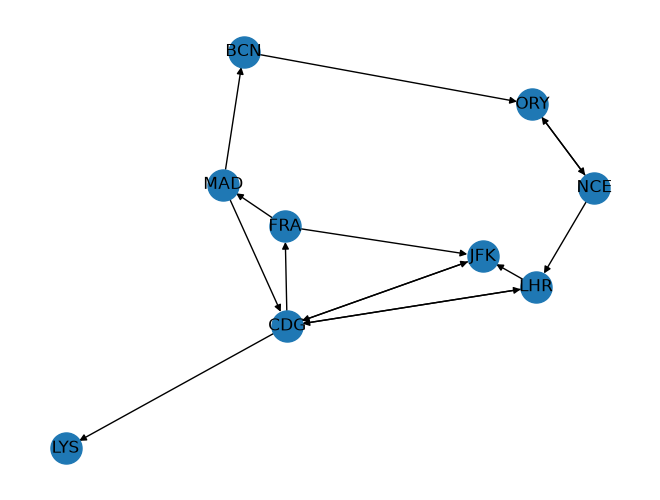

In [ ]:
flights_graph = nx.DiGraph()

for i, row in vol_df.iterrows():
    flights_graph.add_edge(row['source'], row['target'], airline=row['airline'], duration=row['duration_min'], distance=row['distance_km'])


nx.draw(flights_graph, with_labels=True, node_size=500, arrows=True)

In [174]:
flights_graph.out_degree

OutDegreeView({'CDG': 4, 'LHR': 2, 'JFK': 1, 'ORY': 1, 'NCE': 2, 'FRA': 2, 'MAD': 2, 'BCN': 1, 'LYS': 0})

In [177]:
highest_out_degree_node = max(flights_graph.out_degree, key=lambda x: x[1])
print("airport with the highest out-degree:", highest_out_degree_node[0], ":", highest_out_degree_node[1])

highest_in_degree_node = max(flights_graph.in_degree, key=lambda x: x[1])
print("airport with the highest in-degree:", highest_in_degree_node[0], ":", highest_in_degree_node[1])


airport with the highest out-degree: CDG : 4
airport with the highest in-degree: CDG : 3


ValueError: Received invalid argument(s): node_labels

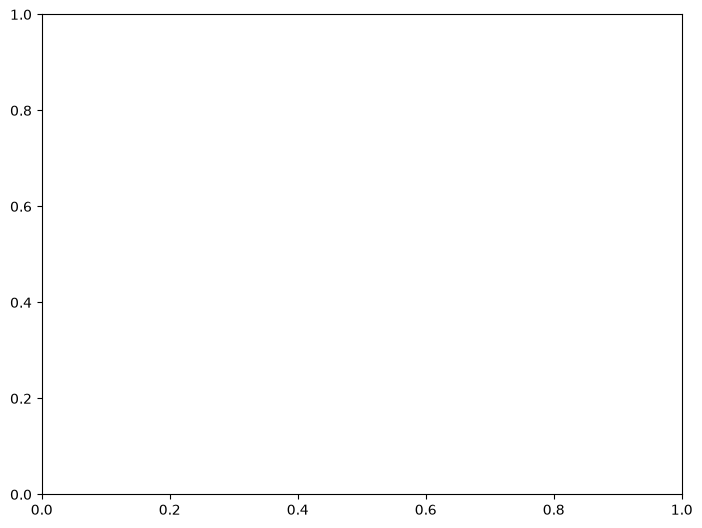

In [ ]:
# let's draw graph with degree information

